In [4]:
# Data and Plotting
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout

In [5]:
columns = [
    'Time_ms', 'Ankle_X', 'Ankle_Y', 'Ankle_Z', 
    'UpperLeg_X', 'UpperLeg_Y', 'UpperLeg_Z', 
    'Trunk_X', 'Trunk_Y', 'Trunk_Z', 'Label'
]

base_dir = r'C:\Users\Red Moon\Coding\Harvard_SRI'
target_file = 'S01R01.txt'
file_path = None

print("Locating dataset...")
for root, dirs, files in os.walk(base_dir):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if not file_path:
    raise FileNotFoundError(f"❌ ERROR: Could not find '{target_file}' anywhere inside {base_dir}.")

print(f"✅ File successfully located at: {file_path}")
df_raw = pd.read_csv(file_path, names=columns, delim_whitespace=True)

Locating dataset...
✅ File successfully located at: C:\Users\Red Moon\Coding\Harvard_SRI\dataset_fog_release\dataset\S01R01.txt


In [6]:
# 1. Clean: Keep active experiment and remap labels (1: Normal -> 0, 2: Freeze -> 1)
df_clean = df_raw[df_raw['Label'] != 0].copy()
df_clean['Label'] = df_clean['Label'].map({1: 0, 2: 1})

# Isolate features and target
X = df_clean.drop(columns=['Time_ms', 'Label'])
y = df_clean['Label']

# 2. Smooth: Apply Exponential Moving Average (EMA)
# 'span' is how much recent data to look at. Weight decays exponentially.
smoothing_window = 15 
X_smoothed = X.ewm(span=smoothing_window, adjust=False).mean()

# 3. Split: MUST use shuffle=False for time-series to prevent data leakage
X_train, X_val, y_train, y_val = train_test_split(
    X_smoothed, y, test_size=0.30, shuffle=False
)

print(f"✅ Data cleaned, smoothed (span={smoothing_window}), and split chronologically!")

✅ Data cleaned, smoothed (span=15), and split chronologically!


In [7]:
# 1. Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# 2. XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=6, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 3. Neural Network
print("Training Neural Network (this might take a moment)...")
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(1, activation='sigmoid') 
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy')
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

print("✅ All baseline models trained!")

Training Random Forest...
Training XGBoost...
Training Neural Network (this might take a moment)...
✅ All baseline models trained!


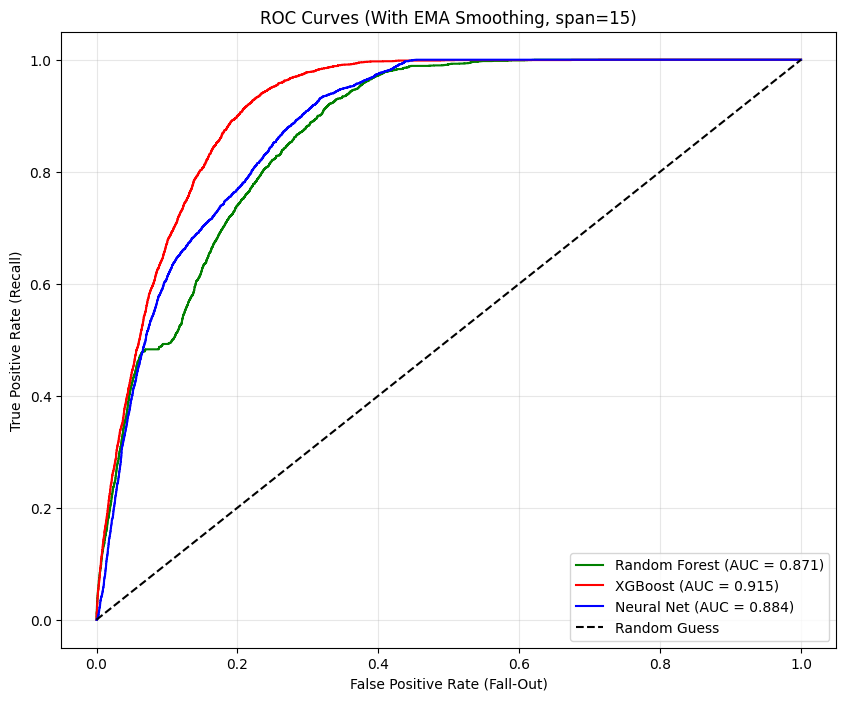

In [8]:
# Get probabilities for the positive class (Freeze)
rf_probs = rf_model.predict_proba(X_val)[:, 1]
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
nn_probs = nn_model.predict(X_val, verbose=0).ravel()

# Plot
plt.figure(figsize=(10, 8))

for name, probs, color in [("Random Forest", rf_probs, "green"), 
                           ("XGBoost", xgb_probs, "red"), 
                           ("Neural Net", nn_probs, "blue")]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title(f'ROC Curves (With EMA Smoothing, span={smoothing_window})')
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [9]:
print("--- Model Complexity (Total Parameters/Nodes) ---")

# Neural Network
print(f"Neural Network: {nn_model.count_params():,} learnable weights/biases")

# Random Forest
rf_nodes = sum([tree.tree_.node_count for tree in rf_model.estimators_])
print(f"Random Forest: {rf_nodes:,} total decision nodes across {rf_model.n_estimators} trees")

# XGBoost
xgb_dump = xgb_model.get_booster().get_dump()
xgb_nodes = sum([tree.count('\n') for tree in xgb_dump])
print(f"XGBoost: ~{xgb_nodes:,} total decision nodes across {xgb_model.n_estimators} trees")

--- Model Complexity (Total Parameters/Nodes) ---
Neural Network: 353 learnable weights/biases
Random Forest: 52,702 total decision nodes across 100 trees
XGBoost: ~7,746 total decision nodes across 100 trees


In [10]:
# Reformat data into 3D sequences [samples, time_steps, features]
def create_sequences(X_data, y_data, time_steps):
    Xs, ys = [], []
    for i in range(len(X_data) - time_steps):
        Xs.append(X_data.iloc[i : (i + time_steps)].values)
        ys.append(y_data.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 15 # The memory window for the RNN
print("Reshaping data for RNN...")
X_seq_train, y_seq_train = create_sequences(X_train, y_train, time_steps)
X_seq_val, y_seq_val = create_sequences(X_val, y_val, time_steps)

# Build the RNN
rnn_model = Sequential([
    SimpleRNN(32, activation='relu', input_shape=(time_steps, X_seq_train.shape[2])),
    Dropout(0.2), # Drops 20% of connections to prevent overfitting
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Recurrent Neural Network (RNN)...")
history_rnn = rnn_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=10, 
    batch_size=64, 
    verbose=1 # Let this one show progress so you know it's working
)

Reshaping data for RNN...
Training Recurrent Neural Network (RNN)...
Epoch 1/10
1015/1015 [==============================] - 2s 2ms/step - loss: 12.8907 - val_loss: 0.5990
Epoch 2/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1621 - val_loss: 0.5201
Epoch 3/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1675 - val_loss: 0.4352
Epoch 4/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1475 - val_loss: 0.3825
Epoch 5/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1465 - val_loss: 0.7573
Epoch 6/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1518 - val_loss: 0.6042
Epoch 7/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1405 - val_loss: 0.3948
Epoch 8/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1357 - val_loss: 0.5493
Epoch 9/10
1015/1015 [==============================] - 2s 2ms/step - loss: 0.1343 - val_loss: 0.5351
Epoch 10/10


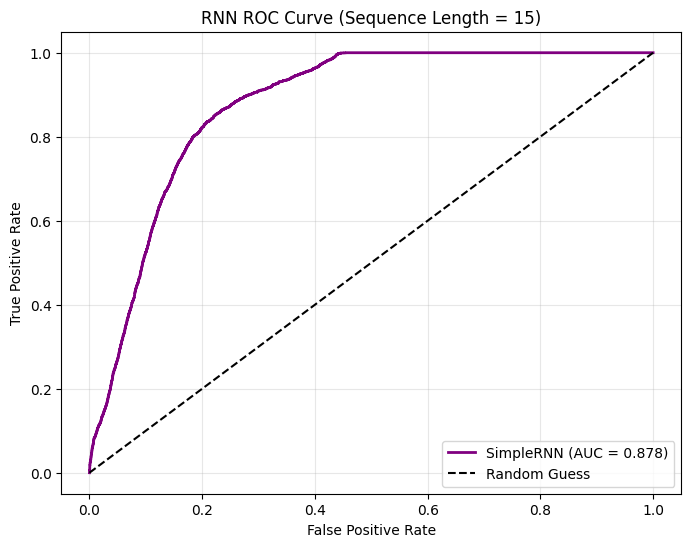

In [11]:
# Get RNN probabilities
rnn_probs = rnn_model.predict(X_seq_val, verbose=0).ravel()
fpr_rnn, tpr_rnn, _ = roc_curve(y_seq_val, rnn_probs)
auc_rnn = auc(fpr_rnn, tpr_rnn)

# Plot RNN ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rnn, tpr_rnn, label=f'SimpleRNN (AUC = {auc_rnn:.3f})', color='purple', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title(f'RNN ROC Curve (Sequence Length = {time_steps})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()